In [1]:
import os; os.environ["CUDA_VISIBLE_DEVICES"] = ""
import numpy as np, torch, torch.nn as nn
torch.set_num_threads(1)           # the models are tiny: more threads only slow the training loops down (about 4x)
from qp_continuous import ContinuousQP
from qp_continuous_ar import Account, plot_shares, plot_curves
from qp_rowwise import RowAccount, shares                  # row-wise Δ: one scalar per asset and weight row, instead of one per asset

d, p, n_days = 12, 6, 6            # assets, market features, training days
lam, sigma   = 1.3, 0.15           # the optimizer's risk aversion, the size of the learner's nudges

rng = np.random.default_rng(0)
X = rng.standard_normal((n_days, p))                                                  # features, one row per day
true_returns = 1 / (1 + np.exp(-2 * X @ rng.standard_normal((d, p)).T / np.sqrt(p)))   # hidden: what the model must learn
F = rng.standard_normal((d, d // 2)) / np.sqrt(d // 2)
Sigma = F @ F.T + 0.25 * np.eye(d)                                                    # hidden: how the assets co-move

In [2]:
Sinv = np.linalg.inv(Sigma); u = Sinv @ np.ones(d)
M, b0 = (Sinv - np.outer(u, u) / u.sum()) / lam, u / u.sum()      # optimizer: portfolio(c) = M c + b0

def value(day, z):                                                # what a portfolio is really worth that day
    return true_returns[day] @ z - lam / 2 * z @ Sigma @ z
best  = [value(i,  M @ true_returns[i] + b0) for i in range(n_days)]
worst = [value(i, -M @ true_returns[i] + b0) for i in range(n_days)]

def black_box(day, predicted_returns):                            # regret: 0 = best possible, 1 = worst
    return (best[day] - value(day, M @ predicted_returns + b0)) / (best[day] - worst[day])

box = ContinuousQP.from_data(X, true_returns, Sigma, lam=lam, sigma=sigma)   # the same box, for the exact critic

In [3]:
class Model(nn.Module):
    def __init__(self, h=8, pos_scale=0.1, train_pos=False, seed=0):
        super().__init__(); torch.manual_seed(seed)
        self.trunk, self.head = nn.Linear(p, h), nn.Linear(h, 1)          # shared by all assets
        pos = torch.randn(d, h) * pos_scale                                 # one code per asset
        if train_pos: 
            self.pos = nn.Parameter(pos)                          # private and trainable
        else:
            self.register_buffer("pos", pos)                      # fixed
        nn.init.zeros_(self.head.weight); nn.init.zeros_(self.head.bias)    # start by predicting 0 for every asset

    def forward(self, x):                                                   # features (..., p) -> returns (..., d)
        return self.head(torch.tanh(self.trunk(x).unsqueeze(-2) + self.pos)).squeeze(-1)

shared = lambda seed: Model(h=8,  pos_scale=0.1, train_pos=False, seed=seed)
private = lambda seed: Model(h=32, pos_scale=1.0, train_pos=True,  seed=seed)

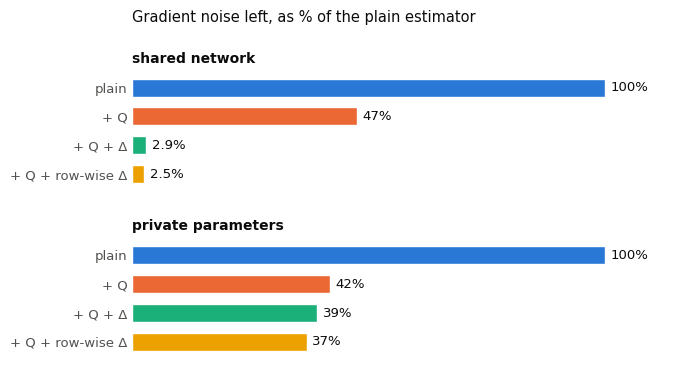

In [4]:
plot_shares({"shared network": shares(box, shared),
             "private parameters": shares(box, private)});

Q alone removes about half of the noise. Δ removes almost all of the rest — but only for the shared network. With private parameters per asset, the leftover noise has no common direction and Δ has nothing to cancel. **The model's design decides whether Δ can work.**

Row-wise Δ uses one scalar per asset and weight row, instead of one scalar per asset. It barely moves the total noise: 2.9% → 2.5% for the shared network, 39% → 37% with private parameters. But the total hides where the noise sits. Training below tells a different story.

In [5]:
Xt = torch.as_tensor(X, dtype=torch.float32)
baseline, surrogates = {}, {}                                  

def plain(model, day, seed):                                  
    mu = model(Xt[day])
    nudged = mu.detach() + sigma * torch.randn(d)             
    score = black_box(day, nudged.numpy())                  
    b = baseline.get(day, score); baseline[day] = 0.9 * b + 0.1 * score    # running average to compare against
    log_prob = -((nudged - mu) ** 2).sum() / (2 * sigma ** 2)
    grads = torch.autograd.grad((score - b) * log_prob, list(model.parameters()))
    return torch.cat([g.flatten() for g in grads])

with_q = lambda model, day, seed: Account(box, model, day).mc("prefix", None,  N=1, seed=seed)[0]
with_q_delta = lambda model, day, seed: Account(box, model, day).mc("prefix", "pre", N=1, seed=seed)[0]
with_q_row = lambda model, day, seed: torch.as_tensor(RowAccount(box, model, day).estimator("row", N=1, seed=seed)[0])
exact = lambda model, day, seed: box.true_grad(model, day)

def train(make_model, gradient, calls=1600, lr=0.01, seed=0, every=50, K=1):     # K: calls to the black box per step
    model = make_model(seed); opt = torch.optim.Adam(model.parameters(), lr=lr); baseline.clear(); surrogates.clear(); log = []
    for step in range(0, calls + 1, K):
        if len(log) <= step // every: 
            log.append(box.regret(model))    # exact regret, for the plot only
        if step == calls: 
            break
        g = gradient(model, (step // K) % n_days, seed * 100000 + step)  # one step: K calls to the black box
        opt.zero_grad(); k = 0
        for prm in model.parameters():
            prm.grad = g[k:k + prm.numel()].view_as(prm).float(); k += prm.numel()
        opt.step()
    return log

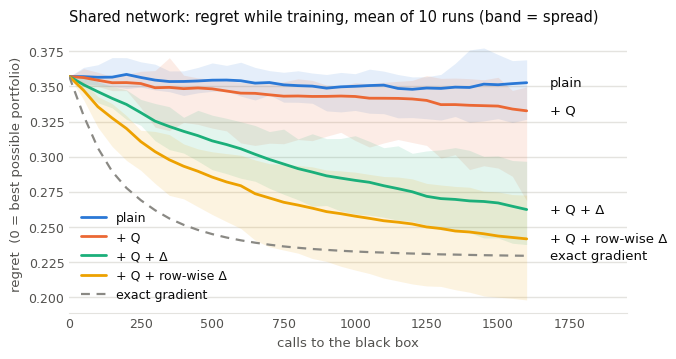

In [6]:
methods = {"plain": plain, "+ Q": with_q, "+ Q + Δ": with_q_delta, "+ Q + row-wise Δ": with_q_row, "exact gradient": exact}
runs = {name: np.array([train(shared, g, seed=s) for s in range(10)]) for name, g in methods.items()}
plot_curves(np.arange(0, 1601, 50), runs, title="Shared network: regret while training");

plain is not drawn: it ends at regret 0.88, worse than the untrained model (0.36)


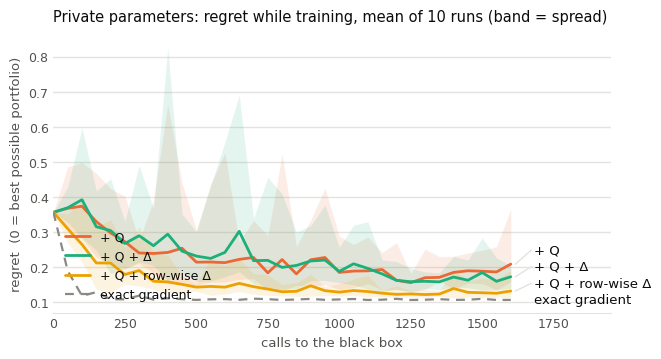

In [7]:
private_runs = {name: np.array([train(private, g, seed=s) for s in range(10)]) for name, g in methods.items()}
print(f"plain is not drawn: it ends at regret {private_runs['plain'][:, -1].mean():.2f}, worse than the untrained model ({private_runs['plain'][:, 0].mean():.2f})")
plot_curves(np.arange(0, 1601, 50), {k: v for k, v in private_runs.items() if k != "plain"}, title="Private parameters: regret while training");

In [8]:
print(f"{'regret: mean over training / final':36s}{'shared network':>18s}{'private parameters':>22s}")
for name in methods:
    print(f"{name:36s}" + "".join(f"{f'{r[name].mean():.3f} / {r[name][:, -1].mean():.3f}':>{w}s}" for r, w in ((runs, 18), (private_runs, 22))))

regret: mean over training / final      shared network    private parameters
plain                                    0.352 / 0.353         1.431 / 0.881
+ Q                                      0.344 / 0.333         0.227 / 0.209
+ Q + Δ                                  0.299 / 0.262         0.232 / 0.173
+ Q + row-wise Δ                         0.277 / 0.242         0.160 / 0.133
exact gradient                           0.249 / 0.230         0.120 / 0.107


Row-wise Δ trains better than scalar Δ on both models, 10 seeds out of 10: regret over training drops by 0.022 on the shared network and by 0.072 with private parameters. On the private model scalar Δ is no better than Q, and row-wise Δ closes about 60% of the gap from Q to the exact gradient.

The total noise barely moves because `head.weight` holds 90%+ of it, and its input tanh(trunk(x) + pos_j) differs per asset, so row-wise Δ cannot touch it. The gain sits in the small blocks. The rows of `trunk.weight`, `trunk.bias` and `head.bias` see the same input for every asset (the day's features x, or 1), so row-wise Δ cancels their noise exactly. Adam scales each parameter on its own, so clean steps in the trunk count even when the total is the same. **Row-wise Δ works on the private model because the trunk is still shared.**

Caveats: exact Q and Δ* (a ceiling), Adam. One scalar per parameter is the far end of the same family and gives the exact gradient on the shared network. 20 seeds and per-block noise fractions: `QP_ROWWISE.md`.


In [9]:
import sys; sys.path.insert(0, ".."); from baselines import group_weights, lax_weights, Surrogate
from multiprocessing import get_context

def nudge(model, day, seed, n):                                          # n nudged predictions and their scores
    J, mu = (x.float() for x in box.jac(model, day))                      # J[j] = d mu_j / d theta, the direction of coordinate j's score
    b = mu + sigma * torch.randn(n, d, generator=torch.Generator().manual_seed(seed))
    return J, mu, b, torch.tensor([black_box(day, x.numpy()) for x in b], dtype=torch.float32)

def reinforce(model, day, seed):                                          # REINFORCE: the score-function estimator, no baseline
    J, mu, b, f = nudge(model, day, seed, 1)
    return (f[:, None] * (b - mu) / sigma ** 2).mean(0) @ J

def grouped(method, K=8):                                                 # RLOO, GRPO, OTB: K nudges per step, the group is the baseline (one per coordinate for OTB)
    def gradient(model, day, seed):
        J, mu, b, f = nudge(model, day, seed, K)
        return group_weights(method, f, (b - mu) / sigma ** 2, torch.arange(d).expand(K, d), (J * J).sum(1)) @ J
    return gradient

def lax(fit="variance", window=128, steps=8):                             # LAX: a surrogate c_phi(b) per day, refit on the day's last `window` nudges after every call
    replay = {}
    def gradient(model, day, seed):
        J, mu, b, f = nudge(model, day, seed, 1)
        if day not in surrogates: surrogates[day] = Surrogate(d); replay[day] = ([], [])
        c = surrogates[day]; g = lax_weights(c, mu, b, f, sigma).detach() @ J
        replay[day][0].append(b[0]); replay[day][1].append(f[0]); B, F = (torch.stack(v[-window:]) for v in replay[day])
        for _ in range(steps):
            if fit == "variance": c.fit(lax_weights(c, mu, B, F, sigma), J @ J.T)                              # the paper's objective: ||g_hat||^2
            else: loss = ((c(B) - F) ** 2).mean(); c.opt.zero_grad(); loss.backward(); c.opt.step()            # regression: (f - c(b))^2
        return g
    return gradient

CALLS, LR = 12800, {1: 0.005, 8: 0.01}                                    # the best of {0.005, 0.01, 0.02} with one call per step and with eight (K = 8 beat 4 for RLOO, GRPO and OTB)
makers = {"REINFORCE": lambda: reinforce, "RLOO": lambda: grouped("RLOO"), "GRPO": lambda: grouped("GRPO"), "OTB": lambda: grouped("OTB"),
          "LAX": lambda: lax(), "LAX, regression-fit surrogate": lambda: lax("regression"), "plain": lambda: plain,
          "+ Q": lambda: with_q, "+ Q + row-wise Δ": lambda: with_q_row, "exact gradient": lambda: exact}
groups = {"RLOO": 8, "GRPO": 8, "OTB": 8}

def job(args):                                                            # one run; the workers are forks of this notebook, one seed and method each
    name, seed = args; K = groups.get(name, 1)
    return name, seed, train(shared, makers[name](), calls=CALLS, lr=LR[K], seed=seed, every=100, K=K)

seeds = range(10); long_runs = {name: [None] * len(seeds) for name in makers}
with get_context("fork").Pool(40) as pool:
    for name, seed, log in pool.imap_unordered(job, [(n, s) for n in makers for s in seeds]): long_runs[name][seed] = np.array(log)
long_runs = {name: np.array(v) for name, v in long_runs.items()}

regret: mean over training / final       12800 calls
REINFORCE                              0.351 / 0.341
RLOO                                   0.332 / 0.319
GRPO                                   0.340 / 0.333
OTB                                    0.335 / 0.321
LAX                                    0.337 / 0.324
LAX, regression-fit surrogate          0.299 / 0.269
plain                                  0.331 / 0.313
+ Q                                    0.316 / 0.293
+ Q + row-wise Δ                       0.240 / 0.225
exact gradient                         0.233 / 0.226


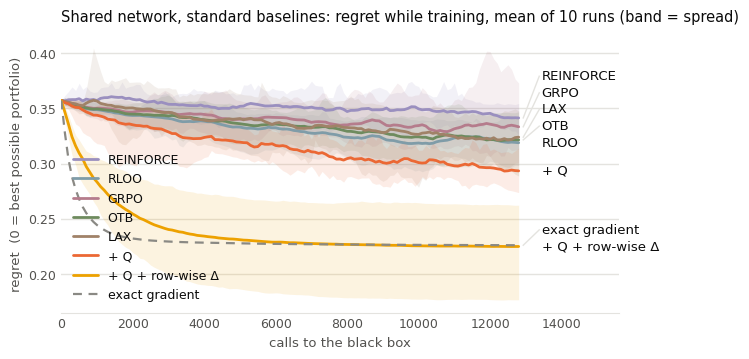

In [10]:
drawn = [n for n in makers if n not in ("plain", "LAX, regression-fit surrogate")]
plot_curves(np.arange(0, CALLS + 1, 100), {n: long_runs[n] for n in drawn}, title="Shared network, standard baselines: regret while training")
print(f"{'regret: mean over training / final':36s}{f'{CALLS} calls':>16s}")
for name in makers:
    print(f"{name:36s}{f'{long_runs[name].mean():.3f} / {long_runs[name][:, -1].mean():.3f}':>16s}")

Standard baselines, same box, same network. REINFORCE is the score-function estimator with no baseline. RLOO, GRPO and OTB draw 8 nudges per step and use the group as the baseline, one per coordinate for OTB. LAX subtracts a learned surrogate c(b) of the score and adds the surrogate's gradient back; the surrogate is refit after every call on the day's last 128 nudges. Each method gets the best learning rate of {0.005, 0.01, 0.02} (0.005 with one call per step, 0.01 with eight) and the better group size of {4, 8} (8 for all three).

None of them moves in 1600 calls. At σ = 0.15 a score-function estimate has a signal-to-noise ratio of about 0.002 per call, so it takes about ten thousand calls to tell them apart. Over 12800 calls the order is **Q + row-wise Δ >> Q > RLOO ≈ OTB ≈ LAX > GRPO > REINFORCE**. REINFORCE without a baseline barely moves, 0.36 to 0.34. The group baselines learn, slowly: the group rebuilds a per-day baseline, which is what the running average of `plain` does with one call per step (0.31 at 12800 calls, table). Q is 0.03-0.04 ahead of the group. Row-wise Δ matches the exact gradient from about 6000 calls on; the others are still 0.07-0.12 above it at 12800.

Caveat, LAX. Fit with the paper's objective (the norm of its own estimate) the surrogate never helps: on the noisiest day the LAX estimate stays noisier than `plain` however long the fit runs. Fit by regression on the same nudges, LAX reaches 0.27 at 12800 calls, better than Q (table, not drawn). With a Gaussian policy LAX differentiates through the surrogate, and that pathwise route is strong here: the gradient of the true f at the nudge has 0.2% of `plain`'s noise. A token policy has no such route. The prefix Q keeps to the form a token policy allows, a score term plus an expectation under the policy.

In [11]:
# The same figure with the Q rows fitted from the black box.  Above, "+ Q" and "+ Q + row-wise Δ" read the true quadratic (cell 1 hands
# `box` the hidden returns and covariance).  Here a reward model f-hat per day, a quadratic in b fitted by least squares to the scores paid
# on that day, takes its place: Q-hat and row-wise Δ-hat are the exact maps of f-hat, and the true f enters only as the paid score of the
# nudge, so the rows stay unbiased for any f-hat.  Everything else (REINFORCE, RLOO, GRPO, OTB, LAX, the exact gradient) is reused as is.
from types import SimpleNamespace
IU = torch.triu_indices(d, d)
def feats(b):                                                              # 1, b, and every b_j b_k: the quadratic features
    return torch.cat([torch.ones(*b.shape[:-1], 1, dtype=b.dtype), b, (b[..., :, None] * b[..., None, :])[..., IU[0], IU[1]]], -1)

class RewardModel:                                                         # f-hat: one quadratic per day, least squares on the day's paid calls
    RIDGES = (1e-3, 1e-2, 1e-1, 1.0)                                       # ridge picked by leave-one-out cross-validation (closed form)
    def __init__(self): self.B, self.F, self.coef = {i: [] for i in range(n_days)}, {i: [] for i in range(n_days)}, {}
    def add(self, day, b, f): self.B[day].append(b.double()); self.F[day].append(float(f)); self.coef.pop(day, None)
    def fit(self, day):
        if day in self.coef: return self.coef[day]
        P = 1 + d + d * (d + 1) // 2; th = torch.zeros(P, dtype=torch.float64); F = torch.tensor(self.F[day], dtype=torch.float64)
        if len(F) == 0:                                                    # nothing paid on this day yet: the mean of the other days
            seen = [f for i in range(n_days) for f in self.F[i]]; th[0] = np.mean(seen) if seen else 0.0
        else:
            order = P if len(F) >= P else 1 + d if len(F) >= 1 + d else 1  # the model grows with the calls: mean, linear, quadratic, each once determined
            Phi = feats(torch.stack(self.B[day]))[:, :order]; G, rhs = Phi.T @ Phi, Phi.T @ F; best = None
            for ridge in (self.RIDGES if order > 1 else (0.0,)):
                R = ridge * torch.eye(order, dtype=torch.float64); R[0, 0] = 0.0; Ainv = torch.linalg.pinv(G + R)      # the intercept is free
                th_r = Ainv @ rhs; h = ((Phi @ Ainv) * Phi).sum(1).clamp_max(1 - 1e-9)
                loo = (((F - Phi @ th_r) / (1 - h)) ** 2).mean()               # leave-one-out squared error
                if best is None or loo < best[0]: best = (loo, th_r)
            th[:order] = best[1]
        self.coef[day] = th; return th
    def box(self):                                                         # what the exact critic reads (a, g, H per day), built from f-hat: no hidden data
        th = [self.fit(i) for i in range(n_days)]; H = []
        for t in th: Hm = torch.zeros(d, d, dtype=torch.float64); Hm[IU[0], IU[1]] = t[1 + d:]; H.append((Hm + Hm.T) / 2)
        fb = SimpleNamespace(a=[float(t[0]) for t in th], g=[t[1:1 + d] for t in th], H=H, sigma=sigma, d=d, o=SimpleNamespace(X=X, n_train=n_days))
        fb.jac = lambda net, i: ContinuousQP.jac(fb, net, i); fb.f = lambda i, b: fb.a[i] + b @ fb.g[i] + torch.einsum("...j,jk,...k->...", b, fb.H[i], b)
        return fb

def fitted(kind, rm):                                                      # kind: None (Q-hat), "scalar" (+ Δ-hat), "row" (+ row-wise Δ-hat)
    def gradient(model, day, seed):
        acc = RowAccount(rm.box(), model, day)                             # the exact maps (Hermite accounting), applied to f-hat
        eps = torch.randn(1, d, generator=torch.Generator().manual_seed(seed), dtype=torch.float64); b = acc.mu[None] + sigma * eps
        f = torch.tensor([black_box(day, b[0].numpy())], dtype=torch.float64)       # the one paid call
        H = acc.cqp.H[day]; fut = torch.cat([H.diagonal().flip(0).cumsum(0).flip(0)[1:], H.new_zeros(1)])
        Q = torch.stack([acc.cqp.f(day, torch.cat([b[:, :j + 1], acc.mu[None, j + 1:]], 1)) + sigma ** 2 * fut[j] for j in range(d)], 1)   # E[f-hat | b_<=j]
        coef = (f[:, None] - Q) * eps / sigma + torch.as_tensor(acc.G)[None] + 2 * (b - acc.mu[None]) @ torch.tril(H, -1).T
        g = (coef @ acc.J).numpy()
        if kind and acc.hermite("prefix"): g = g - acc.hermite_values(eps.numpy()) @ acc.projected(kind)      # Δ-hat, built before this call is added
        rm.add(day, b[0], f[0]); return torch.as_tensor(g[0])
    return gradient

def train_sgd(model, gradient, calls, lr, seed, every=100, K=1):          # plain SGD, lr per call: K averaged calls get K times the step
    opt = torch.optim.SGD(model.parameters(), lr=lr * K); baseline.clear(); surrogates.clear(); log = []
    for step in range(0, calls + 1, K):
        if len(log) <= step // every: r = box.regret(model); log.append(min(r, 1.0) if np.isfinite(r) else 1.0)     # capped at 1, the worst portfolio
        if step == calls: break
        try: g = gradient(model, (step // K) % n_days, seed * 100000 + step)
        except Exception: g = torch.tensor([float("nan")])
        if not torch.isfinite(g).all(): return log + [1.0] * (calls // every + 1 - len(log))                       # a run that blows up scores 1 from there on
        opt.zero_grad(); k = 0
        for prm in model.parameters(): prm.grad = g[k:k + prm.numel()].view_as(prm).float(); k += prm.numel()
        opt.step()
    return log

fitted_makers = {"+ Q": lambda: fitted(None, RewardModel()), "+ Q + Δ": lambda: fitted("scalar", RewardModel()), "+ Q + row-wise Δ": lambda: fitted("row", RewardModel())}
def job_f(args):
    name, seed = args
    return name, seed, train(shared, fitted_makers[name](), calls=CALLS, lr=LR[1], seed=seed, every=100)
fitted_runs = {name: [None] * len(seeds) for name in fitted_makers}
with get_context("fork").Pool(40) as pool:
    for name, seed, log in pool.imap_unordered(job_f, [(n, s) for n in fitted_makers for s in seeds]): fitted_runs[name][seed] = np.array(log)
fitted_runs = {name: np.array(v) for name, v in fitted_runs.items()}

regret: mean over training / final      fitted f-hat          true f
+ Q                                    0.319 / 0.293   0.316 / 0.293
+ Q + Δ                                0.263 / 0.222               -
+ Q + row-wise Δ                       0.254 / 0.212   0.240 / 0.225


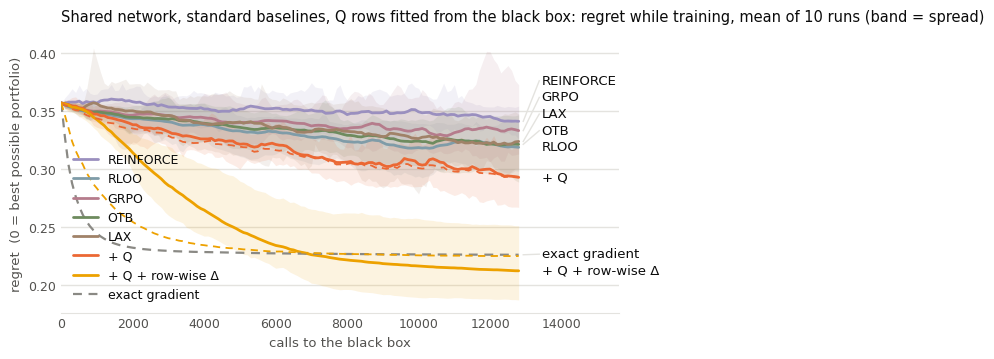

In [12]:
from qp_continuous_ar import _COL
black = {**{n: long_runs[n] for n in ("REINFORCE", "RLOO", "GRPO", "OTB", "LAX")}, "+ Q": fitted_runs["+ Q"], "+ Q + row-wise Δ": fitted_runs["+ Q + row-wise Δ"], "exact gradient": long_runs["exact gradient"]}
ax = plot_curves(np.arange(0, CALLS + 1, 100), black, title="Shared network, standard baselines, Q rows fitted from the black box: regret while training")
for n in ("+ Q", "+ Q + row-wise Δ"):                                       # dashed: the same rows with the true f (the figure above)
    ax.plot(np.arange(0, CALLS + 1, 100), long_runs[n].mean(0), color=_COL[n], linewidth=1.3, linestyle=(0, (4, 3)))
print(f"{'regret: mean over training / final':36s}{'fitted f-hat':>16s}{'true f':>16s}")
for name in fitted_makers:
    ex = long_runs.get(name)
    print(f"{name:36s}{f'{fitted_runs[name].mean():.3f} / {fitted_runs[name][:, -1].mean():.3f}':>16s}{(f'{ex.mean():.3f} / {ex[:, -1].mean():.3f}' if ex is not None else '-'):>16s}")

The same figure with the Q rows fitted from the black box. Nothing here reads the true quadratic: each day has a reward model f-hat, a quadratic in b fitted by least squares to the scores paid on that day (a constant until 13 calls, linear until 91, then quadratic, with the ridge picked by leave-one-out cross-validation), and Q-hat and row-wise Δ-hat are the exact maps of f-hat. The estimator stays unbiased for any f-hat because f-hat is built from the earlier calls only. Everything else is the figure above, reused; dashed, the same two rows with the true f.

The order does not change: **Q + row-wise Δ >> Q > RLOO ≈ OTB ≈ LAX > GRPO > REINFORCE**. Fitted Q is the oracle Q to three digits (0.319 / 0.293 against 0.316 / 0.293): a day's model is exact after 91 calls on that day, 546 of the 12800. Fitted row-wise Δ pays for the model early (mean over the run 0.254 against 0.240) and ends lower (0.212 against 0.225), below the exact gradient's 0.226. That last gap is Adam's: with a noiseless gradient its step is about the learning rate whatever the gradient's size, so the exact rows keep circling the optimum, while a little noise in the estimate damps the step. Fitted Q + Δ, not drawn, is 0.263 / 0.222.

In [13]:
# The same figure under plain SGD for every method: same methods, cold start, 12800 calls, 10 seeds.  A method's usable rate is set by its
# noise, so each gets the best of {0.0003, 0.001, 0.003, 0.01, 0.03, 0.1, 0.3} by mean regret over the run (5 seeds); lr per call, K calls per step get K times the step.
SGD_LR = {"REINFORCE": 0.001, "RLOO": 0.003, "GRPO": 0.001, "OTB": 0.01, "LAX": 0.003, "+ Q": 0.01, "+ Q + row-wise Δ": 0.03, "+ Q (exact)": 0.01, "+ Q + row-wise Δ (exact)": 0.3, "exact gradient": 0.3}
sgd_makers = {**{n: makers[n] for n in ("REINFORCE", "RLOO", "GRPO", "OTB", "LAX", "exact gradient")}, "+ Q": fitted_makers["+ Q"], "+ Q + row-wise Δ": fitted_makers["+ Q + row-wise Δ"],
              "+ Q (exact)": lambda: with_q, "+ Q + row-wise Δ (exact)": lambda: with_q_row}
def job_s(args):
    name, seed = args; K = groups.get(name, 1)
    return name, seed, train_sgd(shared(seed), sgd_makers[name](), CALLS, SGD_LR[name], seed, every=100, K=K)
sgd_runs = {name: [None] * len(seeds) for name in sgd_makers}
with get_context("fork").Pool(40) as pool:
    for name, seed, log in pool.imap_unordered(job_s, [(n, s) for n in sgd_makers for s in seeds]): sgd_runs[name][seed] = np.array(log)
sgd_runs = {name: np.array(v) for name, v in sgd_runs.items()}

regret: mean over training / final       lr  blew up       plain SGD    Adam (above)
REINFORCE                             0.001     0/10   0.356 / 0.349   0.351 / 0.341
RLOO                                  0.003     0/10   0.342 / 0.333   0.332 / 0.319
GRPO                                  0.001     0/10   0.355 / 0.353   0.340 / 0.333
OTB                                    0.01     0/10   0.342 / 0.338   0.335 / 0.321
LAX                                   0.003     0/10   0.342 / 0.332   0.337 / 0.324
exact gradient                          0.3     0/10   0.216 / 0.205   0.233 / 0.226
+ Q                                    0.01     0/10   0.325 / 0.301   0.319 / 0.293
+ Q + row-wise Δ                       0.03     0/10   0.261 / 0.219   0.254 / 0.212
+ Q (exact)                            0.01     0/10   0.324 / 0.305   0.316 / 0.293
+ Q + row-wise Δ (exact)                0.3     0/10   0.212 / 0.201   0.240 / 0.225


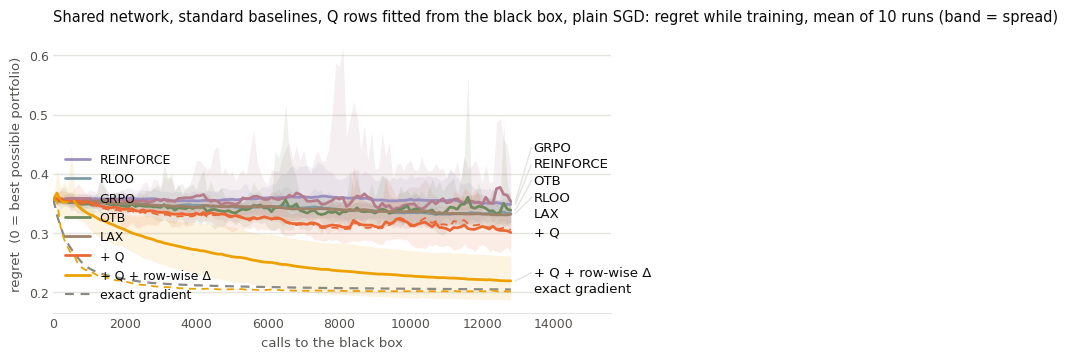

In [14]:
drawn_s = ["REINFORCE", "RLOO", "GRPO", "OTB", "LAX", "+ Q", "+ Q + row-wise Δ", "exact gradient"]
ax = plot_curves(np.arange(0, CALLS + 1, 100), {n: sgd_runs[n] for n in drawn_s}, title="Shared network, standard baselines, Q rows fitted from the black box, plain SGD: regret while training")
for n in ("+ Q", "+ Q + row-wise Δ"):                                       # dashed: the same rows with the true f
    ax.plot(np.arange(0, CALLS + 1, 100), sgd_runs[n + " (exact)"].mean(0), color=_COL[n], linewidth=1.3, linestyle=(0, (4, 3)))
adam = {**{n: long_runs[n] for n in ("REINFORCE", "RLOO", "GRPO", "OTB", "LAX", "exact gradient")}, "+ Q": fitted_runs["+ Q"], "+ Q + row-wise Δ": fitted_runs["+ Q + row-wise Δ"],
        "+ Q (exact)": long_runs["+ Q"], "+ Q + row-wise Δ (exact)": long_runs["+ Q + row-wise Δ"]}
print(f"{'regret: mean over training / final':36s}{'lr':>7}{'blew up':>9}{'plain SGD':>16s}{'Adam (above)':>16s}")
for name in sgd_makers:
    L = sgd_runs[name]
    print(f"{name:36s}{SGD_LR[name]:>7}{f'{int((L[:, -1] >= 1.0).sum())}/{len(L)}':>9}{f'{L.mean():.3f} / {L[:, -1].mean():.3f}':>16s}{f'{adam[name].mean():.3f} / {adam[name][:, -1].mean():.3f}':>16s}")

The same figure under plain SGD. Every method is at the rate it can use, the best of {0.0003, ..., 0.3} by mean regret over the run: REINFORCE and GRPO 0.001, RLOO and LAX 0.003, OTB and Q 0.01, fitted row-wise Δ 0.03, the exact gradient and the oracle row-wise Δ 0.3. Without Adam a method's noise sets its step, so the rates spread over three decades and the curves spread with them: **Q + row-wise Δ (0.261) >> Q (0.325) > RLOO ≈ OTB ≈ LAX (0.342) > GRPO ≈ REINFORCE (0.355)**, mean over the run. No run blew up. GRPO's band is its rescaled advantages, which spike whenever a group's scores nearly agree.

Fitted Q is again the oracle Q (0.325 against 0.324). Fitted row-wise Δ now sits above its oracle row (0.261 against 0.212; final 0.219 against 0.201), where it should: it cannot take 0.3, because while a day's model is a constant or a line its estimate is a plain one, and at 0.1 those early steps already cost more than the rate gains. The oracle row tracks the exact gradient (0.212 against 0.216) at thirty times the rate Q can take. The Adam crossing above is gone: with the step proportional to the gradient, less noise is only better.

In [15]:
# The same comparison from a warm start, with the reward model above.  Protocol as in Live_agent_rowwise.ipynb: one warm start per seed
# shared by every method, f-hat starting empty, plain SGD, a fixed budget.  The same f-hat also serves three surrogate baselines.
from scipy import stats
def surrogate(method, rm):                                                 # the same f-hat used the other ways
    def gradient(model, day, seed):
        J, mu = box.jac(model, day); fb = rm.box(); g_, H_ = fb.g[day], fb.H[day]
        eps = torch.randn(1, d, generator=torch.Generator().manual_seed(seed), dtype=torch.float64); b = mu[None] + sigma * eps
        f = torch.tensor([black_box(day, b[0].numpy())], dtype=torch.float64)
        if method == "LAX (f-hat)": coef = (f - fb.f(day, b))[:, None] * eps / sigma + g_[None] + 2 * b @ H_        # LAX with f-hat as its surrogate: pathwise through f-hat
        elif method == "DM": coef = (g_ + 2 * H_ @ mu)[None]                                                          # direct method: the gradient of E[f-hat] alone, biased
        else: coef = (f - fb.f(day, b))[:, None] * eps / sigma + (g_ + 2 * H_ @ mu)[None]                          # DR: DM plus REINFORCE on the residual f - f-hat
        rm.add(day, b[0], f[0]); return (coef @ J)[0]
    return gradient

Yt = torch.as_tensor(true_returns, dtype=torch.float32)
def warm_start(seed, target=0.30):                                         # supervised steps on the days' returns (the labels, as warm.py's known-good configurations) until regret <= target
    model = shared(seed); opt = torch.optim.Adam(model.parameters(), lr=0.01)
    for step in range(5000):
        if box.regret(model) <= target: break
        opt.zero_grad(); ((model(Xt) - Yt) ** 2).mean().backward(); opt.step()
    return model

LRS, CALLS_W, SEEDS_W = (0.01, 0.03), 3200, range(20)                      # two rates: Q's edge, and past it (a sweep over 0.001-0.3: the exact gradient still trains at 0.3)
CV = {"REINFORCE": lambda: reinforce, "+ Q": lambda: fitted(None, RewardModel()), "+ Q + Δ": lambda: fitted("scalar", RewardModel()), "+ Q + row-wise Δ": lambda: fitted("row", RewardModel()),
      "+ Q (exact)": lambda: with_q, "+ Q + Δ (exact)": lambda: with_q_delta, "+ Q + row-wise Δ (exact)": lambda: with_q_row, "exact gradient": lambda: exact}
BL = {"plain": lambda: plain, "RLOO": lambda: grouped("RLOO"), "GRPO": lambda: grouped("GRPO"), "OTB": lambda: grouped("OTB"), "LAX": lambda: lax(),
      "LAX (f-hat)": lambda: surrogate("LAX (f-hat)", RewardModel()), "DR": lambda: surrogate("DR", RewardModel()), "DM": lambda: surrogate("DM", RewardModel())}
def job_w(args):
    name, lr, seed = args; K = groups.get(name, 1)
    return name, lr, seed, train_sgd(warm_start(seed), {**CV, **BL}[name](), CALLS_W, lr, seed, K=K)
warm_runs = {(n, lr): [None] * len(SEEDS_W) for n in {**CV, **BL} for lr in LRS}
with get_context("fork").Pool(40) as pool:
    for name, lr, seed, log in pool.imap_unordered(job_w, [(n, lr, s) for n in {**CV, **BL} for lr in LRS for s in SEEDS_W]): warm_runs[(name, lr)][seed] = np.array(log)
warm_runs = {k: np.array(v) for k, v in warm_runs.items()}


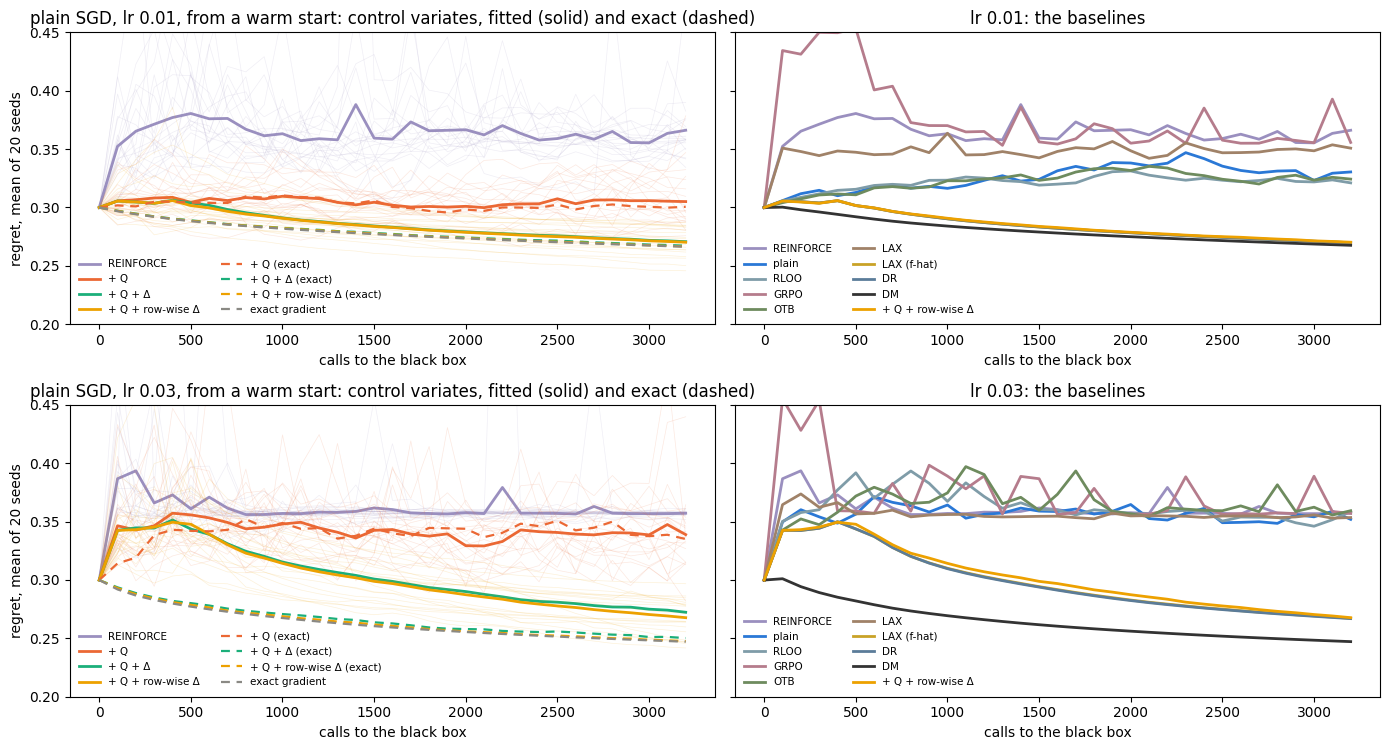

lr 0.01, warm start (regret 0.30), 3200 calls       blew up  mean over the run    final
  REINFORCE                       0/20          0.363       0.366
  + Q                             0/20          0.305       0.305
  + Q + Δ                         0/20          0.286       0.271
  + Q + row-wise Δ                0/20          0.285       0.270
  + Q (exact)                     0/20          0.302       0.301
  + Q + Δ (exact)                 0/20          0.279       0.267
  + Q + row-wise Δ (exact)        0/20          0.279       0.267
  exact gradient                  0/20          0.278       0.266
  plain                           0/20          0.325       0.330
  RLOO                            0/20          0.321       0.321
  GRPO                            0/20          0.376       0.356
  OTB                             0/20          0.322       0.324
  LAX                             0/20          0.347       0.351
  LAX (f-hat)                     0/20          0.285 

In [16]:
_STY = {"REINFORCE": "#9a8fbf", "plain": "#2a78d6", "+ Q": "#eb6834", "+ Q + Δ": "#1baf7a", "+ Q + row-wise Δ": "#eda100", "exact gradient": "#8a8984",
        "RLOO": "#7f9ca8", "GRPO": "#b57c8c", "OTB": "#6e8b5e", "LAX": "#a08268", "LAX (f-hat)": "#c9a227", "DR": "#5b7c99", "DM": "#333333"}
import matplotlib.pyplot as plt
calls_w = np.arange(0, CALLS_W + 1, 100)
fig, ax = plt.subplots(len(LRS), 2, figsize=(14, 3.8 * len(LRS)), sharey=True, squeeze=False)
for row, lr in zip(ax, LRS):
    for a, names in zip(row, (list(CV), ["REINFORCE"] + list(BL) + ["+ Q + row-wise Δ"])):
        for name in names:
            L = warm_runs[(name, lr)]; base = name.replace(" (exact)", ""); ex = name.endswith("(exact)") or name == "exact gradient"
            a.plot(calls_w, L.mean(0), color=_STY[base], ls=(0, (4, 3)) if ex else "-", lw=1.6 if ex else 2, label=name)
            if name in ("REINFORCE", "+ Q", "+ Q + row-wise Δ") and a is row[0]:
                for run in L: a.plot(calls_w, run, color=_STY[base], lw=0.5, alpha=0.15)                                      # the single runs
        a.set(xlabel="calls to the black box", ylim=(0.2, 0.45)); a.legend(fontsize=7.5, ncol=2, frameon=False)
    row[0].set(ylabel=f"regret, mean of {len(SEEDS_W)} seeds", title=f"plain SGD, lr {lr}, from a warm start: control variates, fitted (solid) and exact (dashed)"); row[1].set(title=f"lr {lr}: the baselines")
plt.tight_layout(); plt.show()

for lr in LRS:
    print(f"lr {lr}, warm start (regret 0.30), {CALLS_W} calls{'':6}{'blew up':>8}{'mean over the run':>19}{'final':>9}")
    for name in {**CV, **BL}:
        L = warm_runs[(name, lr)]; print(f"  {name:28s}{int((L[:, -1] >= 1.0).sum()):>5}/{len(L):<3}{L.mean():>14.3f}{L[:, -1].mean():>12.3f}")
    for a, b in [("+ Q + row-wise Δ", "+ Q"), ("+ Q + row-wise Δ", "+ Q + Δ"), ("+ Q + Δ", "+ Q"), ("+ Q", "RLOO"), ("+ Q", "plain"), ("+ Q + row-wise Δ", "REINFORCE"),
                 ("+ Q + row-wise Δ", "DR"), ("+ Q + row-wise Δ", "LAX (f-hat)"), ("DM", "+ Q + row-wise Δ"), ("+ Q + row-wise Δ (exact)", "+ Q + row-wise Δ")]:
        x, y = warm_runs[(a, lr)].mean(1), warm_runs[(b, lr)].mean(1); dlt = x - y      # paired on the seeds, mean over the run (lower is better)
        print(f"    {a:26s} - {b:26s} {dlt.mean():+.3f} ± {dlt.std(ddof=1) / len(dlt) ** 0.5:.3f}   p {stats.ttest_rel(x, y).pvalue:.3f}   {int((dlt < 0).sum())}/{len(dlt)} seeds better")
    print()


**Without the white box.** The rows above read the true quadratic. Here nothing does. Each day has a reward model f-hat, a quadratic in b fitted by least squares to the scores paid on that day; it starts as a constant, becomes linear at 13 calls and quadratic at 91, with the ridge picked by leave-one-out cross-validation. Q, Δ and row-wise Δ are the exact maps of f-hat, and the true f enters only as the paid score of the nudge, so every row is unbiased for any f-hat. The same f-hat serves three more baselines: LAX with f-hat as its surrogate, DM (the gradient of E f-hat and nothing else: biased, the learned-surrogate route of DFL) and DR (DM plus REINFORCE on f − f-hat). Protocol as in `Live_agent_rowwise.ipynb`: every seed starts from the same warm start, supervised steps on the days' returns until the regret is 0.30 (the labels stand in for warm.py's known-good configurations; the black box is not called), f-hat starts empty, plain SGD, 3200 calls, 20 seeds. A run whose weights blow up scores 1 from there on; none did.

Two rates. At lr 0.01, Q's edge: **Q + row-wise Δ ≈ Q + Δ (0.285) > Q (0.305) > RLOO ≈ OTB ≈ plain (0.32) > REINFORCE (0.36)**, mean over the run, each step paired on 16-20 of 20 seeds (p ≤ 0.001). GRPO is below REINFORCE and LAX with its own surrogate barely above it (0.35). At lr 0.03 Q is past its edge, fitted or exact (0.34), and so is every baseline (0.35-0.37); the Δ rows still train (0.30, final 0.27). The two residuals tie at both rates (−0.001 and −0.002, p 0.1): on the shared network scalar Δ already sees cos² 0.95 and leaves the row-wise part nothing to remove. Its own gain is the Adam and private-model story above.

What the reward model costs. The fitted Δ rows are 0.007 behind their exact versions at lr 0.01 and 0.037 at 0.03: while a day's model is a constant or a line the estimator is a plain one, and the larger rate turns those first steps into lost ground. DR and LAX with f-hat tie the Δ rows (within 0.003): once f-hat is exact all three are the exact gradient plus little, and the run is limited by the rate and by the early model, not by the estimator. DM is the best row at both rates (0.280 and 0.265). Backprop through a well-specified surrogate of a noiseless quadratic has no bias to pay. That is the toy's gift to the surrogate route, not a general fact, and the reason the estimator here stays unbiased for any f-hat.